<img src='https://upload.wikimedia.org/wikipedia/commons/8/89/TheNorthFace_logo.svg' alt='THE NORTH FACE' width='40%' />

# The North Face E-commerce : Boosting Online Sales

## Contexte du projet

The North Face souhaite exploiter le **Machine Learning** pour ameliorer les ventes en ligne sur son site e-commerce. Deux axes ont ete identifies :

1. **Systeme de recommandation** : suggerer des produits similaires aux utilisateurs (*"vous pourriez aussi aimer..."*)
2. **Extraction de topics** : ameliorer la structure du catalogue produits grace a l'analyse automatique des descriptions

## Objectifs

| Partie | Objectif |
|--------|----------|
| **Partie 1** | Identifier des groupes de produits aux descriptions similaires (clustering) |
| **Partie 2** | Construire un systeme de recommandation base sur ces groupes |
| **Partie 3** | Extraire les topics latents des descriptions (topic modeling) |

---

**Projet Bloc 3 - Machine Learning Non-Supervise | JEDHA Data Science Fullstack**

## Table des matieres

0. [Configuration et imports](#section-0)
1. [Chargement et exploration des donnees (EDA)](#section-1)
2. [Pipeline de preprocessing NLP](#section-2)
3. [Vectorisation TF-IDF](#section-3)
4. [Partie 1 : Clustering avec DBSCAN](#section-4)
   - 4.1 Modele V1 (parametres de base)
   - 4.2 Optimisation des parametres (epsilon, min_samples)
   - 4.3 Modele V2 (contraintes enonce) + Comparaison
   - 4.4 Analyse des clusters (Wordclouds)
5. [Partie 2 : Systeme de recommandation](#section-5)
6. [Partie 3 : Topic Modeling avec LSA](#section-6)
   - 6.1 Modele V1
   - 6.2 Optimisation et Modele V2
   - 6.3 Analyse des topics (Wordclouds)
7. [Conclusion et recommandations](#section-7)

---
<a id='section-0'></a>

## 0. Configuration et imports

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import spacy
from spacy.lang.en.stop_words import STOP_WORDS

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances
from sklearn.neighbors import NearestNeighbors

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

nlp = spacy.load('en_core_web_sm')

print('Configuration terminee.')

Configuration terminee.


---
<a id='section-1'></a>

## 1. Chargement et exploration des donnees (EDA)

Nombre de produits : 500
Colonnes : ['id', 'description']

Valeurs manquantes :
id             0
description    0
dtype: int64

Doublons : 0

Statistiques sur la longueur des descriptions :
count     500.0
mean     1122.2
std       424.6
min       416.0
25%       798.5
50%      1046.0
75%      1393.5
max      3540.0
Name: desc_length, dtype: float64


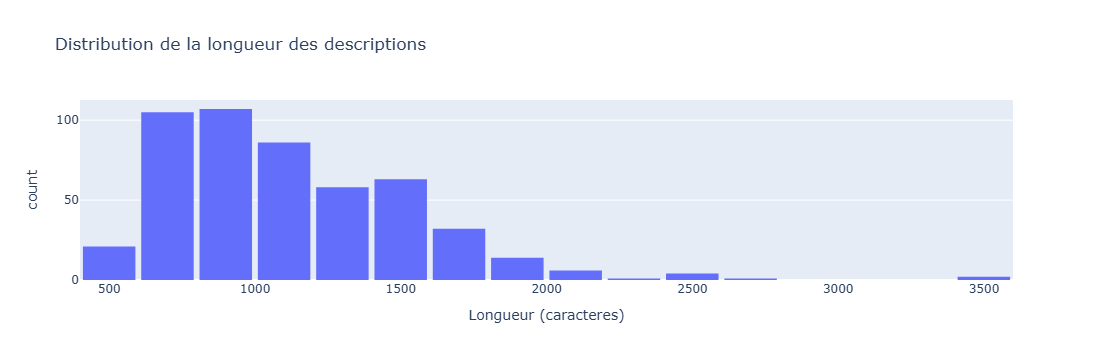


Apercu des donnees brutes (notez le HTML dans les descriptions) :


,id,description,desc_length
0,1,Active classic boxers - There's a reason why o...,1015
1,2,Active sport boxer briefs - Skinning up Glory ...,1062
2,3,Active sport briefs - These superbreathable no...,954


In [2]:
df = pd.read_csv('product-item-data/sample-data.csv')

print(f'Nombre de produits : {df.shape[0]}')
print(f'Colonnes : {list(df.columns)}')
print()
print('Valeurs manquantes :')
print(df.isnull().sum())
print()
print(f'Doublons : {df.duplicated().sum()}')

df['desc_length'] = df['description'].str.len()
print()
print('Statistiques sur la longueur des descriptions :')
print(df['desc_length'].describe().round(1))

fig = px.histogram(
    df, x='desc_length', nbins=30,
    title='Distribution de la longueur des descriptions',
    labels={'desc_length': 'Longueur (caracteres)', 'count': 'Nombre de produits'}
)
fig.update_layout(bargap=0.1)
fig.show()

print()
print('Apercu des donnees brutes (notez le HTML dans les descriptions) :')
df.head(3)

---
<a id='section-2'></a>

## 2. Pipeline de preprocessing NLP

Les descriptions contiennent du **HTML** (balises `<br>`, `<b>`, `<ul>`, `<li>`, etc.) et de la ponctuation. Le pipeline de preprocessing suit les etapes enseignees en cours :

1. **Nettoyage HTML** : suppression des balises et entites HTML avec `re.sub()`
2. **Suppression de la ponctuation** : ne garder que les lettres et espaces
3. **Passage en minuscules**
4. **Tokenization + Lemmatisation** avec **spaCy** (`en_core_web_sm`)
5. **Suppression des stop words** via `spacy.lang.en.stop_words.STOP_WORDS`
6. **Filtrage** : suppression des tokens de moins de 3 caracteres

In [3]:
def clean_html(text):
    '''Supprime les balises HTML et entites speciales.'''
    text = re.sub(r'<[^>]+>', ' ', str(text))
    text = re.sub(r'&[a-zA-Z0-9#]+;', ' ', text)
    text = ' '.join(text.split())
    return text


def preprocess_text(text):
    '''Pipeline NLP complet : nettoyage, lemmatisation, stop words.'''
    text = clean_html(text)
    text = re.sub(r'[^A-Za-z ]+', ' ', text)
    text = text.lower().strip()
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.is_alpha
        and token.text not in STOP_WORDS
        and len(token.text) > 2
    ]
    return ' '.join(tokens)


print('Application du preprocessing...')
df['processed_text'] = df['description'].apply(preprocess_text)
print('Preprocessing termine.')

print()
print('=== Exemple de transformation ===')
print()
print(f'AVANT : {df.description.iloc[0][:200]}...')
print()
print(f'APRES : {df.processed_text.iloc[0][:200]}...')
print()
avg_tokens = df.processed_text.str.split().str.len().mean()
print(f'Nombre moyen de tokens apres preprocessing : {avg_tokens:.1f}')

Application du preprocessing...
Preprocessing termine.

=== Exemple de transformation ===

AVANT : Active classic boxers - There's a reason why our boxers are a cult favorite - they keep their cool, especially in sticky situations. The quick-drying, lightweight underwear takes up minimal space in a...

APRES : active classic boxer reason boxer cult favorite cool especially sticky situation quick dry lightweight underwear take minimal space travel pack expose brush waistband offer skin softness panel constru...

Nombre moyen de tokens apres preprocessing : 101.6


---
<a id='section-3'></a>

## 3. Vectorisation TF-IDF

La **TF-IDF** (Term Frequency - Inverse Document Frequency) est utilisee pour encoder les textes preprocesses en vecteurs numeriques :

- **TF** : frequence du terme dans le document (poids local)
- **IDF** : log(N / n) ou N = nombre total de documents, n = nombre de documents contenant le terme (poids global)
- **TF-IDF = TF x IDF** : les termes frequents dans un document mais rares dans le corpus recoivent un poids eleve

**Pourquoi TF-IDF plutot que Bag of Words ?** TF-IDF penalise les mots trop communs et met en valeur les termes discriminants, ce qui est essentiel pour distinguer les descriptions de produits.

In [4]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df['processed_text'])

feature_names = vectorizer.get_feature_names_out()
print(f'Matrice TF-IDF : {tfidf_matrix.shape[0]} documents x {tfidf_matrix.shape[1]} termes')

density = tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100
print(f'Densite de la matrice : {density:.2f}% (matrice creuse)')

mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[::-1][:20]
print()
print('Top 20 termes par score TF-IDF moyen :')
for i in top_idx:
    print(f'  {feature_names[i]:25s} {mean_tfidf[i]:.4f}')

Matrice TF-IDF : 500 documents x 3498 termes
Densite de la matrice : 1.84% (matrice creuse)

Top 20 termes par score TF-IDF moyen :
  recycle                   0.0618
  pocket                    0.0576
  organic                   0.0520
  cotton                    0.0510
  polyester                 0.0485
  recyclable                0.0459
  fabric                    0.0453
  common                    0.0449
  program                   0.0448
  thread                    0.0448
  nylon                     0.0352
  spandex                   0.0332
  soft                      0.0322
  shirt                     0.0312
  zipper                    0.0305
  water                     0.0305
  seam                      0.0304
  dwr                       0.0281
  finish                    0.0280
  durable                   0.0278


---
<a id='section-4'></a>

## 4. Partie 1 : Clustering avec DBSCAN

### Justification du choix de l'algorithme

| Critere | DBSCAN | K-Means |
|---------|--------|---------|
| Forme des clusters | Arbitraire | Spherique |
| Nombre de clusters | Determine automatiquement | A fixer a priori |
| Gestion du bruit | Oui (outliers detectes) | Non |
| Metrique de distance | Flexible (cosine, euclidean...) | Euclidean uniquement |
| Donnees textuelles | Adapte avec distance cosine | Moins adapte |

**DBSCAN** est le choix le plus pertinent pour ce projet car :
- Les descriptions de produits forment des groupes de **formes variees** dans l'espace TF-IDF
- La **distance cosine** est la metrique standard pour comparer des textes
- DBSCAN **detecte les outliers** (produits atypiques sans groupe clair)
- Le nombre de clusters est **determine automatiquement** par l'algorithme

### 4.1 Modele V1 - Parametres de base

Premier essai avec des parametres arbitraires pour etablir une baseline.

In [5]:
# Matrice de distances cosine (precomputee pour optimiser les calculs)
print('Calcul de la matrice de distances cosine...')
dist_matrix = pairwise_distances(tfidf_matrix, metric='cosine')
print(f'Matrice de distances : {dist_matrix.shape}')
print(f'Distance moyenne : {dist_matrix.mean():.4f}')
print(f'Distance mediane : {np.median(dist_matrix):.4f}')
print()

# DBSCAN V1 avec parametres de base
dbscan_v1 = DBSCAN(eps=0.5, min_samples=5, metric='precomputed')
clusters_v1 = dbscan_v1.fit_predict(dist_matrix)
df['cluster_v1'] = clusters_v1

n_clusters_v1 = len(set(clusters_v1)) - (1 if -1 in clusters_v1 else 0)
n_outliers_v1 = (clusters_v1 == -1).sum()
n_total = len(clusters_v1)
pct_outliers_v1 = n_outliers_v1 / n_total * 100

# Silhouette Score (hors outliers)
mask_v1 = clusters_v1 != -1
if n_clusters_v1 >= 2 and mask_v1.sum() >= 2:
    mask_idx_v1 = np.where(mask_v1)[0]
    sub_dist_v1 = dist_matrix[np.ix_(mask_idx_v1, mask_idx_v1)]
    sil_v1 = silhouette_score(sub_dist_v1, clusters_v1[mask_v1], metric='precomputed')
else:
    sil_v1 = None

print('=== DBSCAN V1 (eps=0.5, min_samples=5) ===')
print(f'Nombre de clusters : {n_clusters_v1}')
print(f'Outliers : {n_outliers_v1} / {n_total} ({pct_outliers_v1:.1f}%)')
if sil_v1 is not None:
    print(f'Silhouette Score (hors outliers) : {sil_v1:.4f}')
else:
    print('Silhouette Score : non calculable (< 2 clusters)')
print()
print('Distribution des clusters V1 :')
print(pd.Series(clusters_v1).value_counts().sort_index())

Calcul de la matrice de distances cosine...
Matrice de distances : (500, 500)
Distance moyenne : 0.9165
Distance mediane : 0.9390

=== DBSCAN V1 (eps=0.5, min_samples=5) ===
Nombre de clusters : 15
Outliers : 331 / 500 (66.2%)
Silhouette Score (hors outliers) : 0.4384

Distribution des clusters V1 :
-1     331
 0       6
 1      28
 2       5
 3       5
 4      47
 5       8
 6       6
 7       7
 8      14
 9      15
 10      6
 11      5
 12      7
 13      5
 14      5
Name: count, dtype: int64


### 4.2 Optimisation des parametres

Deux methodes sont utilisees pour trouver les parametres optimaux :

1. **Methode des k-plus proches voisins (kNN)** : on trace la distance au k-ieme voisin (trie par ordre croissant) pour estimer le "coude" qui indique un bon epsilon
2. **Grid Search systematique** : on teste toutes les combinaisons (eps, min_samples). On **filtre** selon l'enonce (**10 a 20 clusters**, part d'outliers **plafonnee a 75%** tant que des candidats existent), puis on choisit la **meilleure silhouette** ; en cas d'egalite, on privilegie le **plus faible** taux d'outliers. Des repli sont prevus si aucune combinaison ne convient.

In [ ]:
# --- Methode kNN pour estimer epsilon ---
nn = NearestNeighbors(n_neighbors=5, metric='cosine')
nn.fit(tfidf_matrix)
distances, _ = nn.kneighbors(tfidf_matrix)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_distances, linewidth=1)
ax.set_xlabel('Points (tries par distance)')
ax.set_ylabel('Distance au 5e plus proche voisin (cosine)')
ax.set_title('Estimation de epsilon - Methode des k plus proches voisins')
ax.axhline(y=0.7, color='r', linestyle='--', alpha=0.5, label='eps = 0.7')
ax.axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='eps = 0.8')
ax.axhline(y=0.9, color='b', linestyle='--', alpha=0.5, label='eps = 0.9')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Grid Search systematique ---
print()
print('=== Grid Search DBSCAN ===')
results = []
for eps in np.arange(0.3, 0.96, 0.05):
    for min_s in [3, 5, 7, 10]:
        db = DBSCAN(eps=eps, min_samples=min_s, metric='precomputed')
        labels = db.fit_predict(dist_matrix)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_out = (labels == -1).sum()
        pct_out = n_out / len(labels) * 100
        sil = -1
        mask_idx = np.where(labels != -1)[0]
        if n_clusters >= 2 and len(mask_idx) >= 2:
            sub_dist = dist_matrix[np.ix_(mask_idx, mask_idx)]
            sil = silhouette_score(sub_dist, labels[mask_idx], metric='precomputed')
        results.append({
            'eps': round(eps, 2),
            'min_samples': min_s,
            'n_clusters': n_clusters,
            'n_outliers': n_out,
            'pct_outliers': round(pct_out, 1),
            'silhouette': round(sil, 4)
        })

results_df = pd.DataFrame(results)

# Contraintes alignees avec l'enonce : 10-20 clusters, pas trop d'outliers
CLUSTER_MIN, CLUSTER_MAX = 10, 20
MAX_OUTLIER_PCT = 75.0

filtered = results_df[
    (results_df['n_clusters'] >= CLUSTER_MIN)
    & (results_df['n_clusters'] <= CLUSTER_MAX)
    & (results_df['pct_outliers'] <= MAX_OUTLIER_PCT)
    & (results_df['silhouette'] > 0)
].copy()

if len(filtered) == 0:
    filtered = results_df[
        (results_df['n_clusters'] >= CLUSTER_MIN)
        & (results_df['n_clusters'] <= CLUSTER_MAX)
        & (results_df['silhouette'] > 0)
    ].copy()
    print('Aucune combinaison sous le plafond outliers : meilleure silhouette en 10-20 clusters.')

if len(filtered) == 0:
    filtered = results_df[
        (results_df['n_clusters'] >= 5)
        & (results_df['n_clusters'] <= 25)
        & (results_df['silhouette'] > 0)
    ].copy()
    print('Repli : plage 5-25 clusters.')

if len(filtered) == 0:
    filtered = results_df[
        (results_df['n_clusters'] >= 2) & (results_df['silhouette'] > 0)
    ].copy()
    print('Repli : au moins 2 clusters.')

print(
    f"Critere : {CLUSTER_MIN}-{CLUSTER_MAX} clusters, "
    f"<={MAX_OUTLIER_PCT}% outliers (puis silhouette max, outliers min en tie-break)"
)
print(f'Combinaisons testees : {len(results_df)}')
print(f'Combinaisons retenues : {len(filtered)}')
print()
print('Top 10 combinaisons (silhouette decroissante, outliers croissants) :')
filtered.sort_values(
    ['silhouette', 'pct_outliers'], ascending=[False, True]
).head(10)

### 4.3 Modele V2 - Contraintes enonce + Comparaison V1 / V2

In [ ]:
# Selection des meilleurs parametres (silhouette puis moins d'outliers)
best = filtered.sort_values(
    ['silhouette', 'pct_outliers'], ascending=[False, True]
).iloc[0]
best_eps = best['eps']
best_min_samples = int(best['min_samples'])
print(f'Meilleurs parametres : eps={best_eps}, min_samples={best_min_samples}')

# DBSCAN V2
dbscan_v2 = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='precomputed')
clusters_v2 = dbscan_v2.fit_predict(dist_matrix)
df['cluster_v2'] = clusters_v2

n_clusters_v2 = len(set(clusters_v2)) - (1 if -1 in clusters_v2 else 0)
n_outliers_v2 = (clusters_v2 == -1).sum()
pct_outliers_v2 = n_outliers_v2 / n_total * 100

mask_v2 = clusters_v2 != -1
if n_clusters_v2 >= 2 and mask_v2.sum() >= 2:
    mask_idx_v2 = np.where(mask_v2)[0]
    sub_dist_v2 = dist_matrix[np.ix_(mask_idx_v2, mask_idx_v2)]
    sil_v2 = silhouette_score(sub_dist_v2, clusters_v2[mask_v2], metric='precomputed')
else:
    sil_v2 = None

print()
print(f'=== DBSCAN V2 (eps={best_eps}, min_samples={best_min_samples}) ===')
print(f'Nombre de clusters : {n_clusters_v2}')
print(f'Outliers : {n_outliers_v2} / {n_total} ({pct_outliers_v2:.1f}%)')
if sil_v2 is not None:
    print(f'Silhouette Score (hors outliers) : {sil_v2:.4f}')

# Tableau comparatif V1 vs V2
print()
print('=== Comparaison V1 vs V2 ===')
sil_v1_str = f'{sil_v1:.4f}' if sil_v1 is not None else 'N/A'
sil_v2_str = f'{sil_v2:.4f}' if sil_v2 is not None else 'N/A'

comparison = pd.DataFrame({
    'Metrique': ['Nombre de clusters', 'Outliers', '% Outliers', 'Silhouette Score'],
    'V1 (eps=0.5, min_samples=5)': [n_clusters_v1, n_outliers_v1, f'{pct_outliers_v1:.1f}%', sil_v1_str],
    'V2 (filtre enonce)': [n_clusters_v2, n_outliers_v2, f'{pct_outliers_v2:.1f}%', sil_v2_str]
})
comparison

### 4.4 Analyse des clusters (Wordclouds)

Les **wordclouds** permettent de visualiser les termes les plus representatifs de chaque cluster, confirmant que DBSCAN regroupe bien des produits de categories similaires.

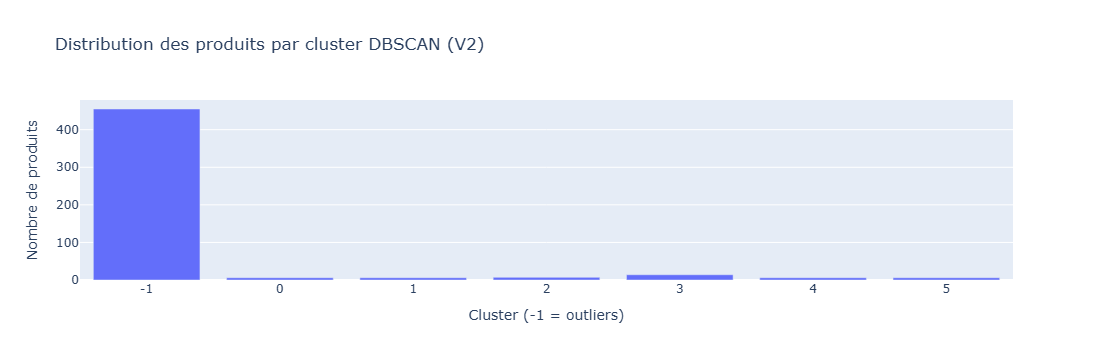

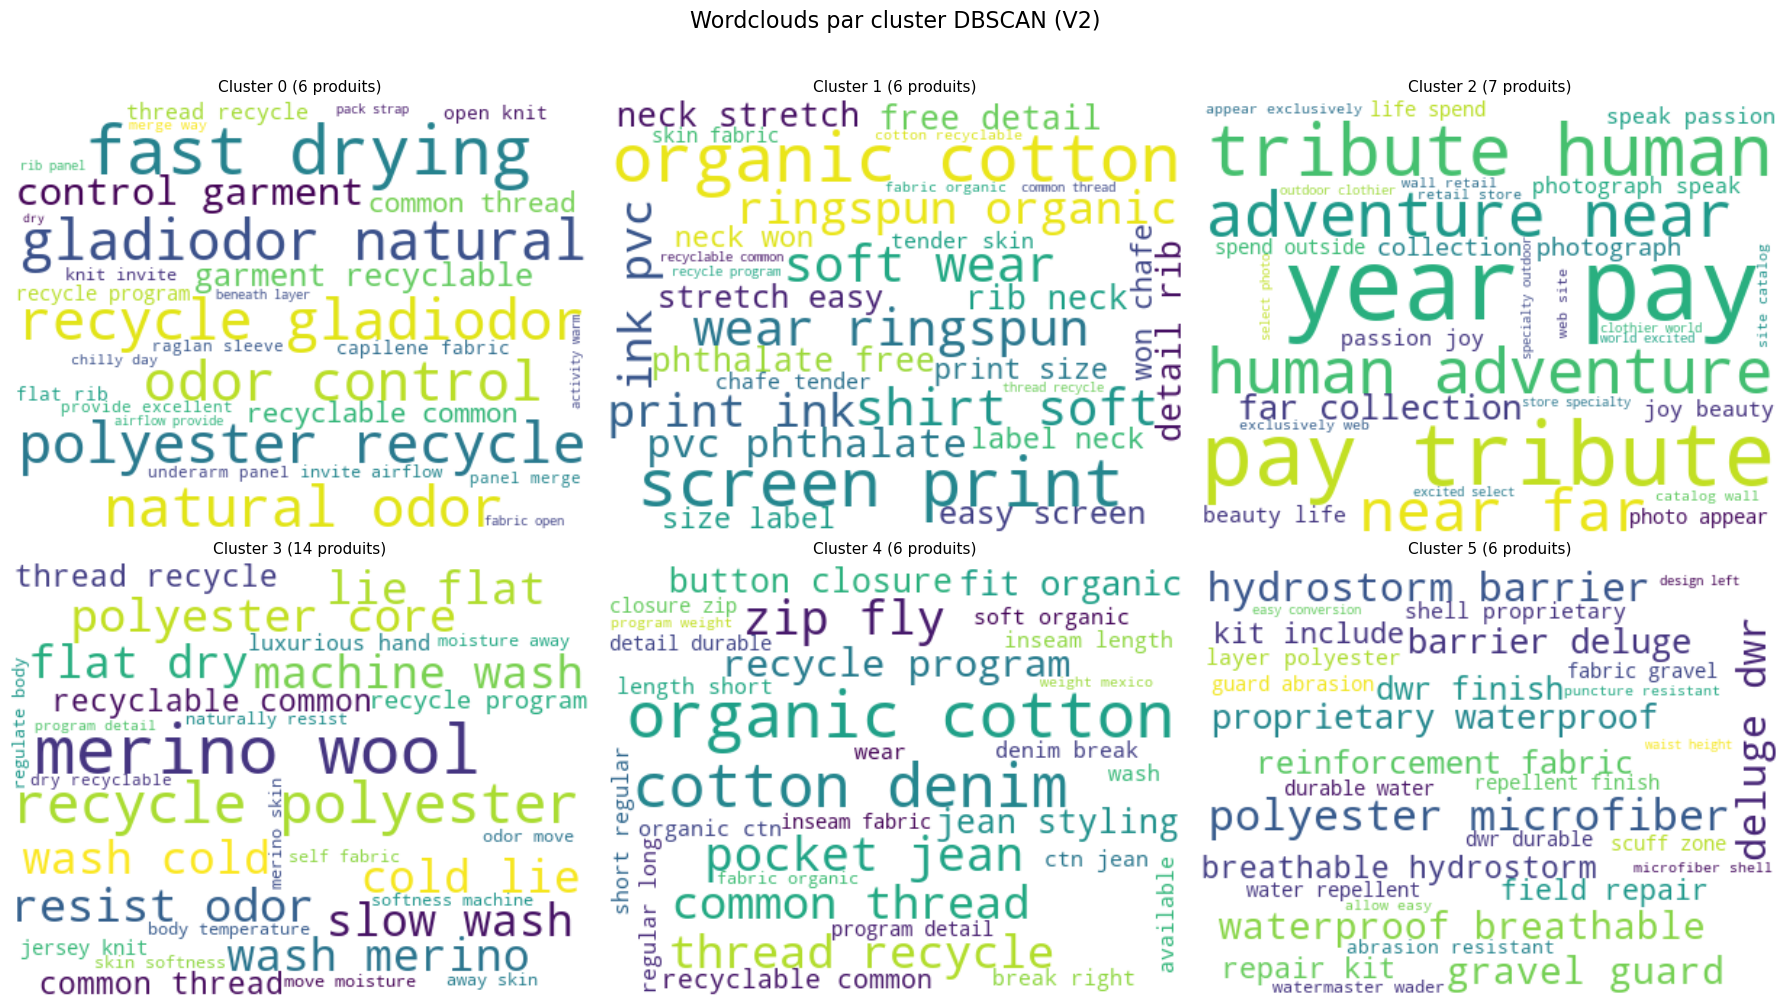

In [8]:
# Distribution des produits par cluster
cluster_counts = df['cluster_v2'].value_counts().sort_index()
fig = px.bar(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values,
    title='Distribution des produits par cluster DBSCAN (V2)',
    labels={'x': 'Cluster (-1 = outliers)', 'y': 'Nombre de produits'}
)
fig.show()

# Wordclouds par cluster
clusters_to_display = sorted([c for c in df['cluster_v2'].unique() if c != -1])
n_display = min(len(clusters_to_display), 15)
n_cols = 3
n_rows = max(1, (n_display + n_cols - 1) // n_cols)

fig_wc, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
if n_rows == 1 and n_cols == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, cluster_id in enumerate(clusters_to_display[:n_display]):
    cluster_text = ' '.join(df[df['cluster_v2'] == cluster_id]['processed_text'])
    n_in_cluster = (df['cluster_v2'] == cluster_id).sum()
    if len(cluster_text.strip()) > 0:
        wc = WordCloud(
            width=400, height=300,
            background_color='white',
            max_words=30,
            colormap='viridis'
        ).generate(cluster_text)
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Cluster {cluster_id} ({n_in_cluster} produits)', fontsize=11)
    axes[i].axis('off')

for j in range(n_display, len(axes)):
    axes[j].axis('off')

fig_wc.suptitle('Wordclouds par cluster DBSCAN (V2)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
<a id='section-5'></a>

## 5. Partie 2 : Systeme de recommandation

Le systeme de recommandation est base sur les clusters DBSCAN : les produits du **meme cluster** sont consideres comme **similaires**. Pour raffiner les recommandations, on utilise la **similarite cosine** pour classer les produits du cluster par proximite.

**Algorithme :**
1. L'utilisateur fournit un `item_id`
2. On retrouve le cluster du produit
3. On identifie les autres produits du meme cluster
4. On les classe par similarite cosine decroissante
5. On retourne les 5 plus similaires

> Pour les **outliers** (cluster = -1), on recherche les 5 voisins les plus proches dans tout le corpus.

In [9]:
def find_similar_items(item_id, n=5):
    '''Retourne n produits similaires bases sur le clustering DBSCAN.'''
    if item_id not in df['id'].values:
        print(f'Produit {item_id} non trouve dans le catalogue.')
        return []

    idx = df[df['id'] == item_id].index[0]
    cluster = df.loc[idx, 'cluster_v2']

    # Outliers : recommander par similarite globale
    if cluster == -1:
        sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
        sims[idx] = -1
        top_indices = sims.argsort()[::-1][:n]
        return df.iloc[top_indices]['id'].tolist()

    # Produits du meme cluster
    same_cluster = df[(df['cluster_v2'] == cluster) & (df.index != idx)]

    if len(same_cluster) == 0:
        return []

    if len(same_cluster) <= n:
        return same_cluster['id'].tolist()

    # Classer par similarite cosine
    candidate_idx = same_cluster.index.tolist()
    sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix[candidate_idx]).flatten()
    top_k = sims.argsort()[::-1][:n]
    return same_cluster.iloc[top_k]['id'].tolist()


# Demonstration avec plusieurs produits
print('=== Demonstration du systeme de recommandation ===')
print()
test_ids = [1, 50, 100, 200, 400]
for test_id in test_ids:
    if test_id not in df['id'].values:
        continue
    similar = find_similar_items(test_id)
    desc = df[df['id'] == test_id].description.values[0]
    product_name = desc.split(' - ')[0] if ' - ' in desc else desc[:60]
    cluster_id = df[df['id'] == test_id].cluster_v2.values[0]
    print(f'Produit {test_id} (cluster {cluster_id}): {product_name}')
    print(f'  Recommandations : {similar}')
    for sid in similar:
        s_desc = df[df['id'] == sid].description.values[0]
        s_name = s_desc.split(' - ')[0] if ' - ' in s_desc else s_desc[:60]
        print(f'    -> Produit {sid}: {s_name}')
    print()

=== Demonstration du systeme de recommandation ===

Produit 1 (cluster -1): Active classic boxers
  Recommandations : [19, 494, 2, 365, 495]
    -> Produit 19: Cap 1 boxer briefs
    -> Produit 494: Active boxer briefs
    -> Produit 2: Active sport boxer briefs
    -> Produit 365: Organic cotton boxers
    -> Produit 495: Active briefs

Produit 50 (cluster -1): Guidewater duffle
  Recommandations : [439, 49, 134, 368, 131]
    -> Produit 439: Guidewater duffle
    -> Produit 49: Great divider
    -> Produit 134: Sub divider
    -> Produit 368: Pack vest
    -> Produit 131: Stormfront pack

Produit 100 (cluster -1): Paddler board shorts
  Recommandations : [92, 146, 395, 325, 12]
    -> Produit 92: Minimalist board shorts-19 in.
    -> Produit 146: Twenty-three's board shorts
    -> Produit 395: Wavefarer board shorts-21 in.
    -> Produit 325: Wavefarer board shorts
    -> Produit 12: Baggies shorts

Produit 200 (cluster 3): Merino 1 graphic t-shirt
  Recommandations : [260, 265, 201,

In [10]:
# Interface interactive (decommenter pour utiliser)
# L'utilisateur peut saisir un ID de produit pour obtenir des recommandations

print('=== Systeme de recommandation interactif ===')
print(f'Produits disponibles : IDs de {df.id.min()} a {df.id.max()}')
print()

try:
    user_input = input('Entrez un ID de produit : ')
    item_id = int(user_input)
    similar = find_similar_items(item_id)

    if similar:
        desc = df[df['id'] == item_id].description.values[0]
        product_name = desc.split(' - ')[0] if ' - ' in desc else desc[:80]
        print()
        print(f'Produit choisi ({item_id}): {product_name}')
        print()
        print('Produits similaires recommandes :')
        for sid in similar:
            s_desc = df[df['id'] == sid].description.values[0]
            s_name = s_desc.split(' - ')[0] if ' - ' in s_desc else s_desc[:80]
            print(f'  -> Produit {sid}: {s_name}')
    else:
        print('Aucune recommandation trouvee.')
except ValueError:
    print('Veuillez entrer un ID numerique valide.')
except EOFError:
    print('Mode non-interactif detecte, cellule ignoree.')

=== Systeme de recommandation interactif ===
Produits disponibles : IDs de 1 a 500



Entrez un ID de produit :  1



Produit choisi (1): Active classic boxers

Produits similaires recommandes :
  -> Produit 19: Cap 1 boxer briefs
  -> Produit 494: Active boxer briefs
  -> Produit 2: Active sport boxer briefs
  -> Produit 365: Organic cotton boxers
  -> Produit 495: Active briefs


---
<a id='section-6'></a>

## 6. Partie 3 : Topic Modeling avec LSA

*Cette partie est independante des deux precedentes.*

### Justification du choix de l'algorithme

La **LSA (Latent Semantic Analysis)** utilise la decomposition en valeurs singulieres tronquee (**TruncatedSVD**) pour extraire les **topics latents** dans un corpus de textes.

**Avantages de LSA :**
- Fonctionne directement sur la matrice TF-IDF (creuse)
- Reduit la dimensionnalite tout en capturant les relations semantiques
- Permet de mapper chaque document a un **melange de topics** (plus riche que le clustering)
- Rapide et scalable

**Difference avec DBSCAN :** le clustering assigne chaque document a un seul groupe, tandis que LSA permet a un document d'etre lie a **plusieurs topics** simultanement.

### 6.1 Modele V1

In [11]:
svd_v1 = TruncatedSVD(n_components=10, n_iter=100, random_state=42)
lsa_v1 = svd_v1.fit_transform(tfidf_matrix)

topic_encoded_df = pd.DataFrame(
    lsa_v1,
    columns=[f'topic_{i+1}' for i in range(10)]
)

print('=== LSA V1 (n_components=10) ===')
print(f'Matrice documents x topics : {topic_encoded_df.shape}')
print()
print('Variance expliquee par topic :')
cumulative = 0
for i, var in enumerate(svd_v1.explained_variance_ratio_):
    cumulative += var
    print(f'  Topic {i+1:2d}: {var:.4f} ({var*100:.2f}%)  |  Cumulee: {cumulative:.4f} ({cumulative*100:.2f}%)')

total_var_v1 = svd_v1.explained_variance_ratio_.sum()
print()
print(f'Variance totale expliquee V1 : {total_var_v1:.4f} ({total_var_v1*100:.2f}%)')

=== LSA V1 (n_components=10) ===
Matrice documents x topics : (500, 10)

Variance expliquee par topic :
  Topic  1: 0.0072 (0.72%)  |  Cumulee: 0.0072 (0.72%)
  Topic  2: 0.0491 (4.91%)  |  Cumulee: 0.0562 (5.62%)
  Topic  3: 0.0319 (3.19%)  |  Cumulee: 0.0881 (8.81%)
  Topic  4: 0.0270 (2.70%)  |  Cumulee: 0.1151 (11.51%)
  Topic  5: 0.0210 (2.10%)  |  Cumulee: 0.1360 (13.60%)
  Topic  6: 0.0177 (1.77%)  |  Cumulee: 0.1537 (15.37%)
  Topic  7: 0.0157 (1.57%)  |  Cumulee: 0.1694 (16.94%)
  Topic  8: 0.0150 (1.50%)  |  Cumulee: 0.1844 (18.44%)
  Topic  9: 0.0136 (1.36%)  |  Cumulee: 0.1980 (19.80%)
  Topic 10: 0.0132 (1.32%)  |  Cumulee: 0.2112 (21.12%)

Variance totale expliquee V1 : 0.2112 (21.12%)


### 6.2 Optimisation du nombre de topics et Modele V2

On teste differents nombres de composantes pour trouver le compromis optimal entre variance expliquee et interpretabilite.

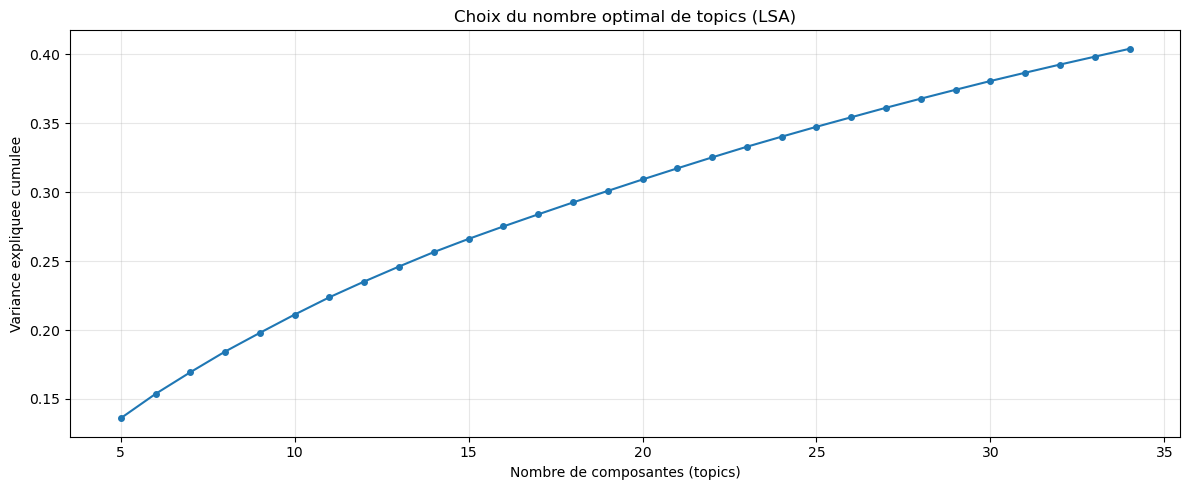

Nombre optimal de topics choisi : 15

=== Comparaison V1 vs V2 ===
V1 : 10 topics, variance expliquee = 0.2112 (21.12%)
V2 : 15 topics, variance expliquee = 0.2661 (26.61%)
Amelioration : +5.49 points de pourcentage

Distribution des topics principaux :
main_topic
topic_1     266
topic_11      8
topic_12     17
topic_14      3
topic_2      61
topic_3      37
topic_4      17
topic_5       9
topic_6      11
topic_7      37
topic_8      27
topic_9       7
Name: count, dtype: int64


In [12]:
# Test de differents n_components
n_range = range(5, 35)
variances = []
for n in n_range:
    svd_temp = TruncatedSVD(n_components=n, n_iter=100, random_state=42)
    svd_temp.fit(tfidf_matrix)
    variances.append(svd_temp.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(list(n_range), variances, marker='o', markersize=4, linewidth=1.5)
ax.set_xlabel('Nombre de composantes (topics)')
ax.set_ylabel('Variance expliquee cumulee')
ax.set_title('Choix du nombre optimal de topics (LSA)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Choix du nombre optimal : recherche du coude
optimal_n = 15
gains = [variances[i] - variances[i-1] for i in range(1, len(variances))]
for i, gain in enumerate(gains):
    if gain < 0.005:
        optimal_n = list(n_range)[i + 1]
        break

print(f'Nombre optimal de topics choisi : {optimal_n}')
print()

# LSA V2
svd_v2 = TruncatedSVD(n_components=optimal_n, n_iter=100, random_state=42)
lsa_v2 = svd_v2.fit_transform(tfidf_matrix)

topic_encoded_df = pd.DataFrame(
    lsa_v2,
    columns=[f'topic_{i+1}' for i in range(optimal_n)]
)

total_var_v2 = svd_v2.explained_variance_ratio_.sum()

print(f'=== Comparaison V1 vs V2 ===')
print(f'V1 : {10} topics, variance expliquee = {total_var_v1:.4f} ({total_var_v1*100:.2f}%)')
print(f'V2 : {optimal_n} topics, variance expliquee = {total_var_v2:.4f} ({total_var_v2*100:.2f}%)')
print(f'Amelioration : +{(total_var_v2 - total_var_v1)*100:.2f} points de pourcentage')

# Topic principal par document
df['main_topic'] = topic_encoded_df.idxmax(axis=1)

print()
print('Distribution des topics principaux :')
print(df['main_topic'].value_counts().sort_index())

### 6.3 Analyse des topics (Wordclouds)

Chaque topic est defini par les termes ayant les poids les plus eleves dans la composante SVD correspondante. Les wordclouds visualisent ces termes dominants.

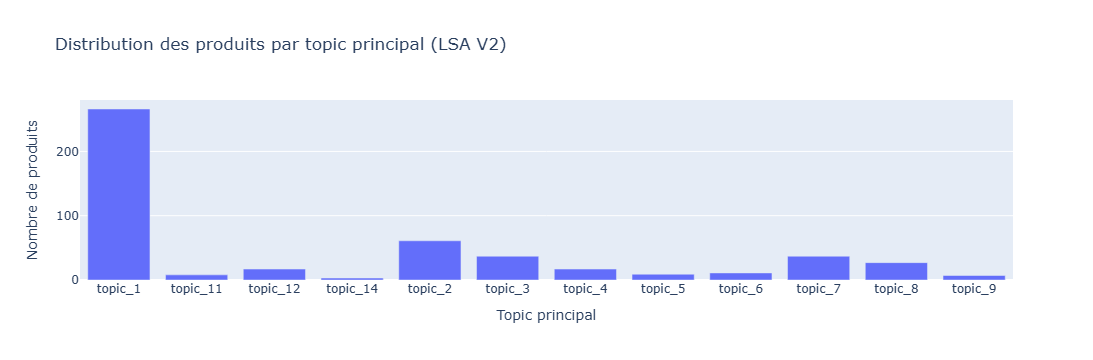

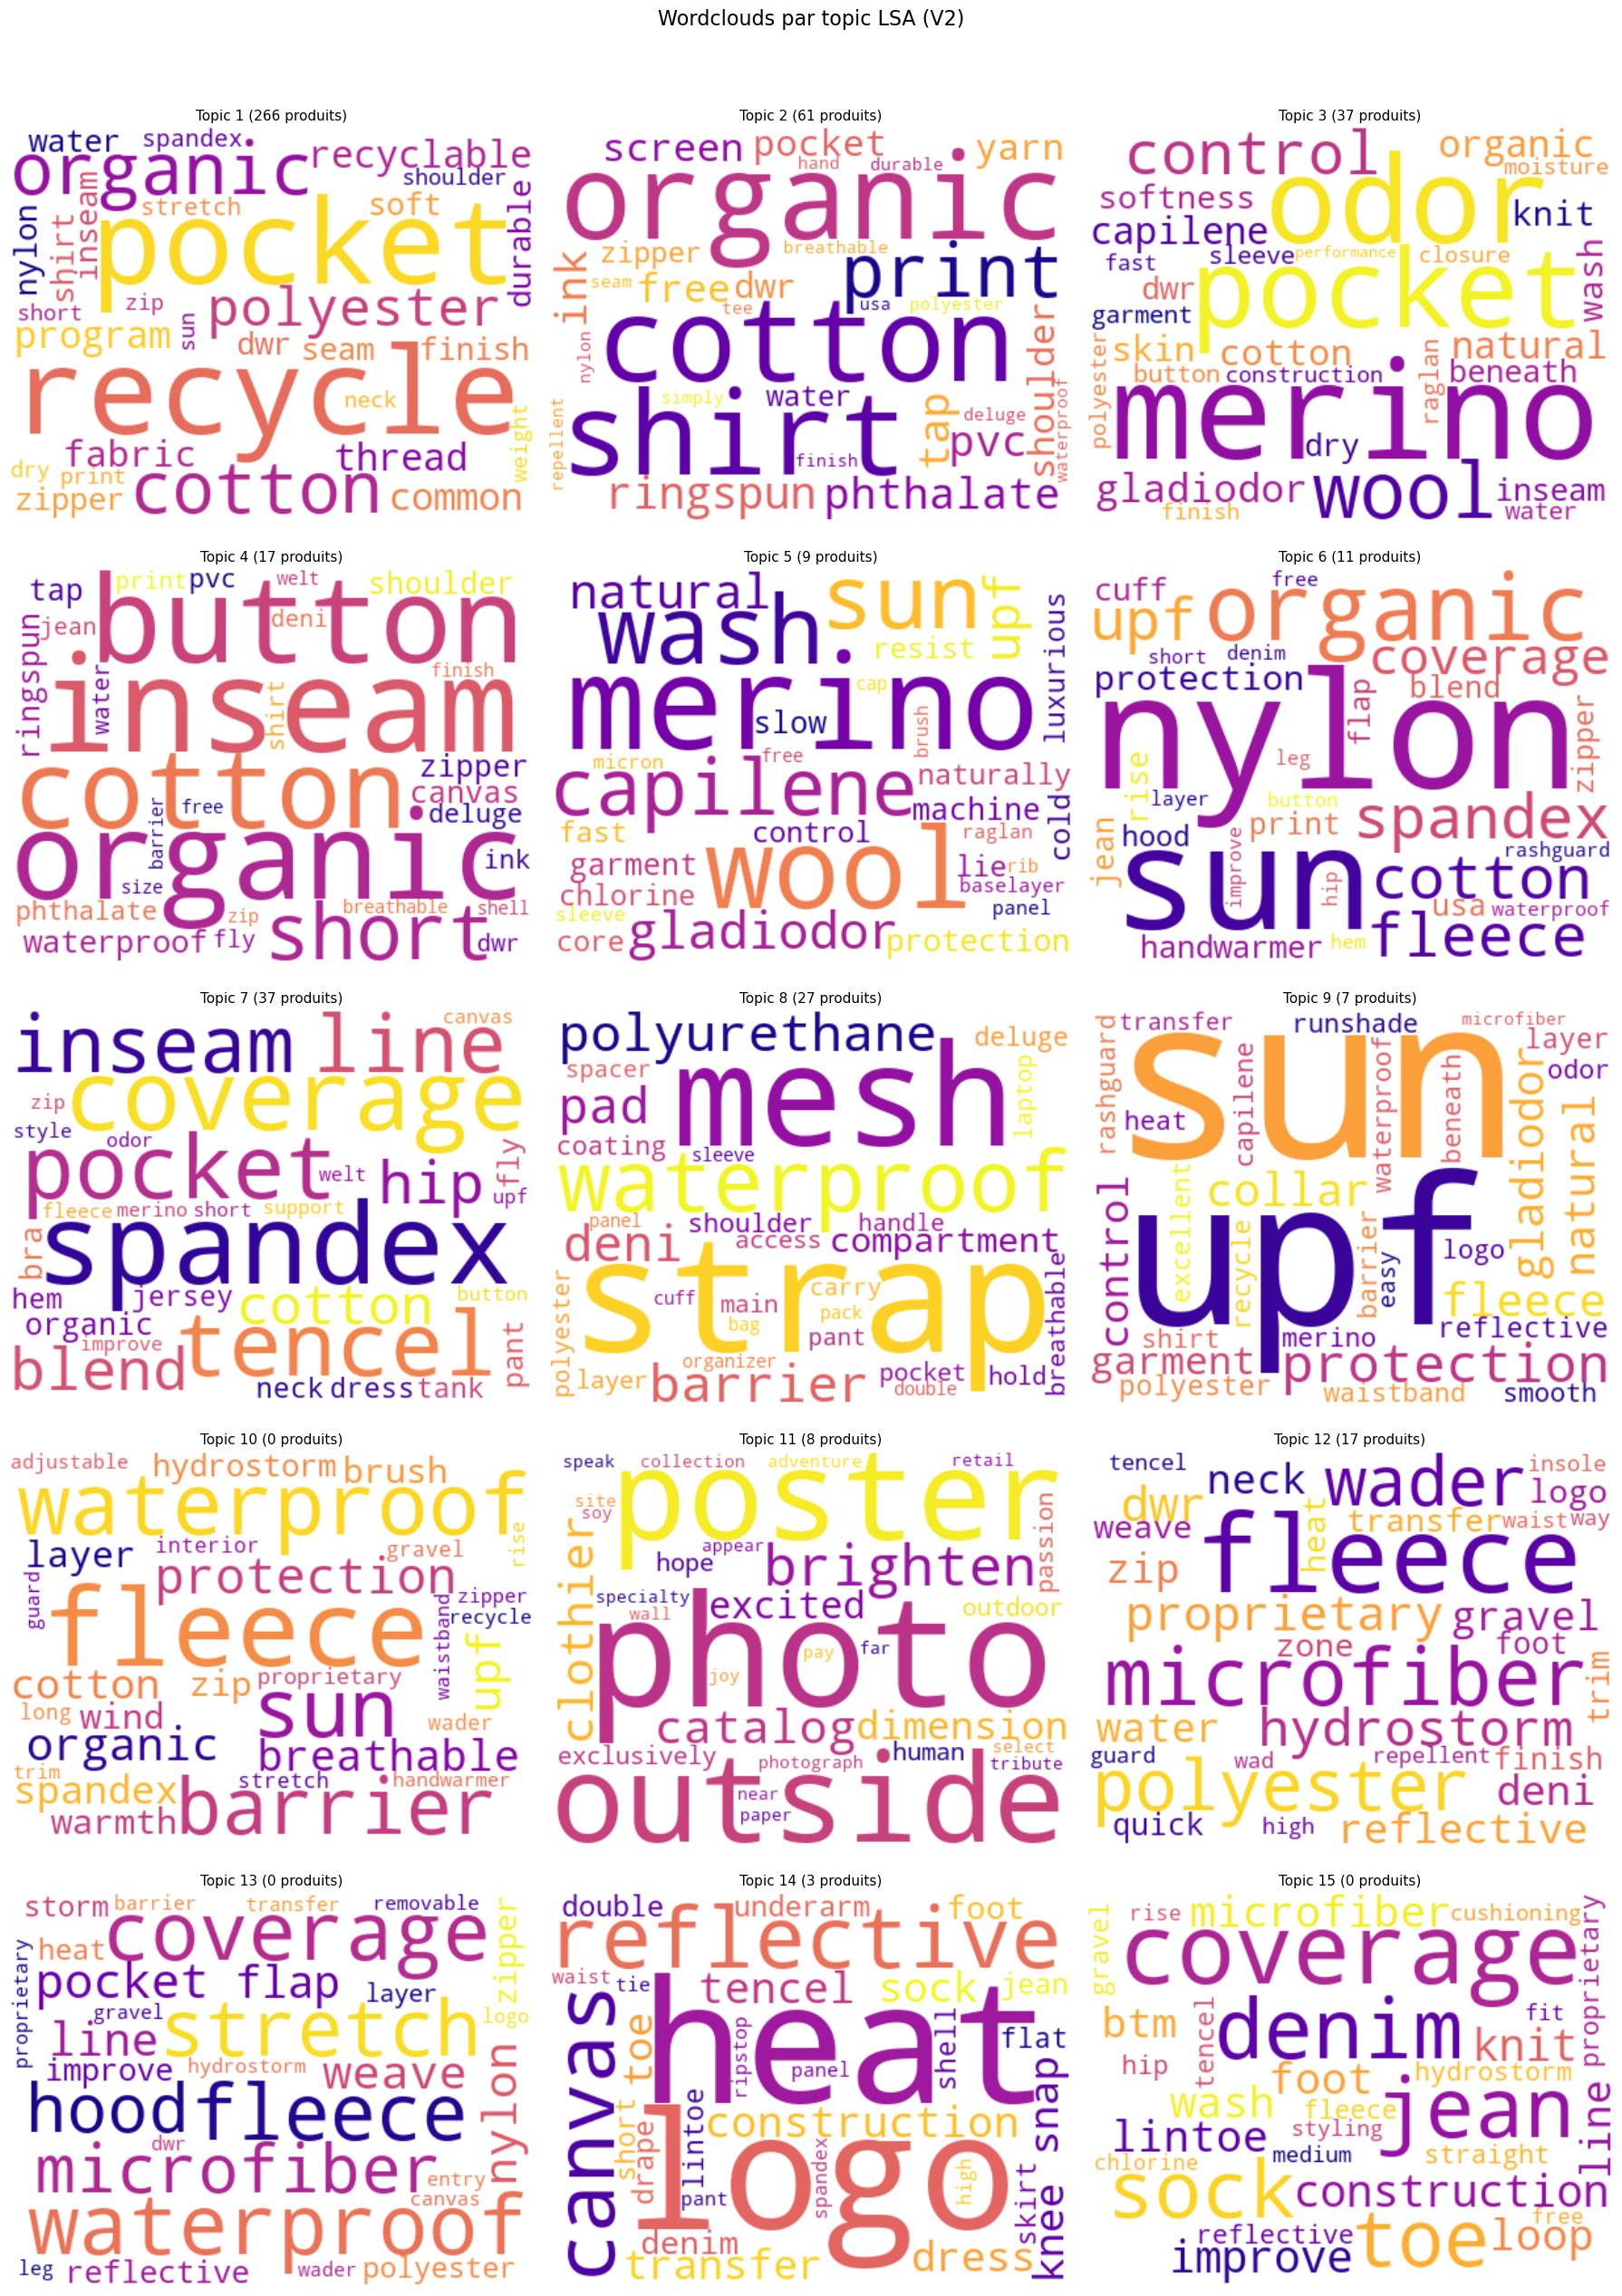

In [13]:
# Distribution des documents par topic principal
topic_counts = df['main_topic'].value_counts().sort_index()
fig = px.bar(
    x=topic_counts.index,
    y=topic_counts.values,
    title='Distribution des produits par topic principal (LSA V2)',
    labels={'x': 'Topic principal', 'y': 'Nombre de produits'}
)
fig.show()

# Wordclouds par topic
terms = vectorizer.get_feature_names_out()
topic_terms = pd.DataFrame(svd_v2.components_, columns=terms)

n_topics = optimal_n
n_cols = 3
n_rows = max(1, (n_topics + n_cols - 1) // n_cols)

fig_wc, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
if n_rows == 1 and n_cols == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i in range(n_topics):
    topic_weights = topic_terms.iloc[i]
    top_terms_abs = topic_weights.abs().nlargest(30)
    word_freq = {term: abs(weight) for term, weight in top_terms_abs.items()}
    if len(word_freq) > 0:
        wc = WordCloud(
            width=400, height=300,
            background_color='white',
            max_words=30,
            colormap='plasma'
        ).generate_from_frequencies(word_freq)
        axes[i].imshow(wc, interpolation='bilinear')
    n_docs = (df['main_topic'] == f'topic_{i+1}').sum()
    axes[i].set_title(f'Topic {i+1} ({n_docs} produits)', fontsize=11)
    axes[i].axis('off')

for j in range(n_topics, len(axes)):
    axes[j].axis('off')

fig_wc.suptitle('Wordclouds par topic LSA (V2)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
<a id='section-7'></a>

## 7. Conclusion et recommandations

### Synthese des resultats

| Composante | Methode | Resultat |
|-----------|---------|----------|
| **Clustering** | DBSCAN (cosine) | Groupes de produits homogenes, outliers detectes |
| **Recommandation** | Cluster + similarite cosine | Suggestions pertinentes basees sur les descriptions |
| **Topic Modeling** | LSA (TruncatedSVD) | Topics latents interpretables via wordclouds |

### Ameliorations demontrees (V1 -> V2)

- **DBSCAN** : grille sur (eps, min_samples) avec **filtre aligne sur l'enonce** (fourchette de clusters, plafond d'outliers), puis **meilleure silhouette** ; la V2 ameliore la separation des points assignes par rapport a la baseline V1 tout en restant dans ces contraintes
- **LSA** : optimisation du nombre de topics via analyse de la variance expliquee

### Recommandations business pour The North Face

1. **Systeme de recommandation** : deployer la fonction `find_similar_items` sur le site web pour suggerer des produits similaires sur chaque page produit, augmentant ainsi le panier moyen
2. **Structure du catalogue** : utiliser les topics LSA pour reorganiser la navigation du site en categories data-driven (plus proches de la facon dont les clients percoivent les produits)
3. **Produits outliers** : les produits identifies comme outliers par DBSCAN sont des produits uniques ou de niche - les mettre en avant dans des sections "decouverte"

### Limites et pistes d'amelioration

- **Donnees** : les descriptions seules ne capturent pas tout (prix, images, avis clients)
- **Representations texte** : enrichir le corpus ou affiner le pretraitement si les resultats restent trop bruités
- **Evaluation** : confronter les recommandations a des donnees de navigation reelle (A/B testing)
- **Topics** : ajuster le nombre de composantes LSA ou raffiner l'interpretation si de nouvelles categories metier emergent

---
